# 6. A nonstationary hindcast

**What this shows:** a complete SWAN hindcast off Perth for 1 January 2023, with
bathymetry, hourly winds and boundary spectra from a regional wave model, and how to
check and analyse the results.

**Prerequisites:** tutorials [1](01_first_model.ipynb) to
[5](05_model_settings.ipynb).

**You will learn:**

- how to set up a nonstationary computation and choose its time step
- how to write maps, tables and spectra at output points, at a chosen interval
- how to check that SWAN ran correctly
- how to read and plot the results with xarray, pandas and wavespectra

**Data used:** `etopo15s_perth.nc` (bathymetry), `era5-20230101.nc` (hourly winds)
and `ww3-spectra-20230101-short.nc` (3-hourly boundary spectra).

## Setup

In [1]:
import shutil
import subprocess
from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import wavespectra
import xarray as xr
from rompy.logging import config as logging_config

logging_config.update(level="WARNING")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "06_nonstationary_hindcast"
shutil.rmtree(OUT_DIR, ignore_errors=True)

## 1. Period and time step

A nonstationary computation follows the waves in time. The interval of the run
period is SWAN's computational time step. The
[SWAN manual](https://swanmodel.sourceforge.io/online_doc/swanuse/node34.html)
advises at most 10 minutes, with the Courant number (how many grid cells a wave
crosses per step) below 10. The longest swell here crosses about 5 cells of 2 km in
10 minutes.

In [2]:
from rompy.core.time import TimeRange

period = TimeRange(start="2023-01-01T00:00", end="2023-01-02T00:00", interval="10m")

## 2. Grid and inputs

The grid, bathymetry, winds and boundary spectra of the previous tutorials.

In [3]:
from rompy.core.filters import Filter
from rompy.core.source import SourceFile, SourceWavespectra
from rompy_swan.boundary import Boundnest1
from rompy_swan.components.cgrid import REGULAR
from rompy_swan.data import SwanDataGrid
from rompy_swan.grid import SwanGrid
from rompy_swan.interface import BoundaryInterface, DataInterface
from rompy_swan.subcomponents.spectrum import SPECTRUM

grid = SwanGrid(x0=114.5, y0=-32.8, dx=0.02, dy=0.02, nx=71, ny=66)
cgrid = REGULAR(grid=grid.component, spectrum=SPECTRUM(mdc=36, flow=0.04, fhigh=1.0))
inpgrid = DataInterface(
    bottom=SwanDataGrid(
        var="bottom",
        source=SourceFile(uri=DATA_DIR / "etopo15s_perth.nc"),
        z1="z",
        fac=-1.0,
        coords={"x": "longitude", "y": "latitude"},
        buffer=0.1,
    ),
    input=[
        SwanDataGrid(
            var="wind",
            source=SourceFile(uri=DATA_DIR / "era5-20230101.nc"),
            z1="u10",
            z2="v10",
            coords={"x": "longitude", "y": "latitude"},
            filter=Filter(sort={"coords": ["latitude"]}),
            buffer=0.25,
        )
    ],
)
boundary = BoundaryInterface(
    kind=Boundnest1(
        id="ww3",
        source=SourceWavespectra(
            uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
        ),
        sel_method="idw",
        sel_method_kwargs={"tolerance": 1.5},
        spacing=0.1,
    )
)

## 3. Startup and physics

`MODE NONSTATIONARY`, and the coastal physics of [Tutorial 5](05_model_settings.ipynb).

In [4]:
from rompy_swan.components.group import PHYSICS, STARTUP
from rompy_swan.components.physics import BREAKING_CONSTANT, FRICTION_JONSWAP, GEN3, TRIAD
from rompy_swan.components.startup import COORDINATES, MODE, PROJECT, SET
from rompy_swan.subcomponents.startup import SPHERICAL

startup = STARTUP(
    project=PROJECT(name="Perth hindcast", nr="t06"),
    set=SET(direction_convention="nautical"),
    mode=MODE(kind="nonstationary"),
    coordinates=COORDINATES(kind=SPHERICAL()),
)
physics = PHYSICS(
    gen=GEN3(),
    breaking=BREAKING_CONSTANT(alpha=1.0, gamma=0.73),
    friction=FRICTION_JONSWAP(cfjon=0.038),
    triad=TRIAD(),
)

## 4. Output

SWAN writes output at named sets of locations:

- `POINTS` defines four sites: offshore, north-west of Rottnest Island, off Cottesloe
  Beach and off Mandurah;
- `BLOCK` writes maps on the computational grid (`COMPGRID`);
- `TABLE` writes a table of values at the points;
- `SPECOUT` writes the 2D spectra at the points.

Output starts with the run. `TimeRangeOpen(delt=...)` writes every hour instead of
every time step.

In [5]:
from rompy_swan.components.group import OUTPUT
from rompy_swan.components.output import BLOCK, POINTS, SPECOUT, TABLE
from rompy_swan.subcomponents.time import TimeRangeOpen

sites = {
    "offshore": (114.80, -32.10),
    "rottnest": (115.40, -31.90),
    "cottesloe": (115.71, -31.98),
    "mandurah": (115.66, -32.50),
}
hourly = TimeRangeOpen(delt=timedelta(hours=1))
output = OUTPUT(
    points=POINTS(
        sname="sites",
        xp=[x for x, _ in sites.values()],
        yp=[y for _, y in sites.values()],
    ),
    block=BLOCK(
        sname="COMPGRID",
        fname="swangrid.nc",
        output=["depth", "hsign", "tps", "dir", "wind"],
        times=hourly,
    ),
    table=TABLE(
        sname="sites",
        format="header",
        fname="sites.txt",
        output=["time", "depth", "hsign", "tps", "dir", "wind"],
        times=hourly,
    ),
    specout=SPECOUT(sname="sites", fname="spectra.nc", times=hourly),
)

## 5. The computation

`COMPUTE_NONSTAT` steps through the run period. `initstat=True` first computes a
stationary wave field for the start time, so the run does not start from calm seas.

In [6]:
from rompy_swan.components.group import LOCKUP
from rompy_swan.components.lockup import COMPUTE_NONSTAT
from rompy_swan.config import SwanConfig

config = SwanConfig(
    startup=startup,
    cgrid=cgrid,
    inpgrid=inpgrid,
    boundary=boundary,
    physics=physics,
    output=output,
    lockup=LOCKUP(compute=COMPUTE_NONSTAT(initstat=True)),
)

## 6. Generate and run

The `COMPUTE` commands take their times from the run period.

In [7]:
from rompy.model import ModelRun

modelrun = ModelRun(run_id="hindcast", period=period, output_dir=OUT_DIR, config=config)
workspace = Path(modelrun())
input_file = (workspace / "INPUT").read_text()
print("\n".join(line for line in input_file.splitlines() if line.startswith("COMPUTE")))

COMPUTE STATIONARY time=20230101.000000
COMPUTE NONSTATIONARY tbegc=20230101.000000 deltc=600.0 SEC tendc=20230102.000000


The run takes a few minutes.

In [8]:
from rompy.backends import DockerConfig


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


if docker_available():
    backend = DockerConfig(image="ghcr.io/rom-py/swan:41.51", executable="swan.exe")
    ok = modelrun.run(backend, workspace_dir=workspace)
    print("SWAN finished" if ok else "SWAN failed")
else:
    print("Docker is not available, skipping the model run")

SWAN finished


## 7. Check the run

SWAN can stop a computation because of an error and still exit normally, so always
read the `PRINT` file. It repeats the commands, lists the settings SWAN used, and
reports warnings and errors. For example, with a 20-minute time step this model
stops with: *"It is inadvisable to use the higher order scheme for nonstationary
computation with CFL greater than 10"*.

In [9]:
def swan_messages(workspace: Path) -> list[str]:
    """Return the error and warning lines from SWAN's PRINT file."""
    lines = (workspace / "PRINT").read_text().splitlines()
    return [line.strip() for line in lines if "** Error" in line or "** Warning" in line]


if (workspace / "PRINT").exists():
    messages = swan_messages(workspace)
    errors = [line for line in messages if "Error" in line]
    print(f"{len(errors)} errors, {len(messages) - len(errors)} warnings")
    if messages:
        print("\n".join(messages))

0 errors, 0 warnings


## 8. Maps

The maps have one field per hour. The southerly wind strengthens from the morning
and peaks around midday, adding a wind sea to the swell that arrives from the
south-west. The red triangles are the output points.

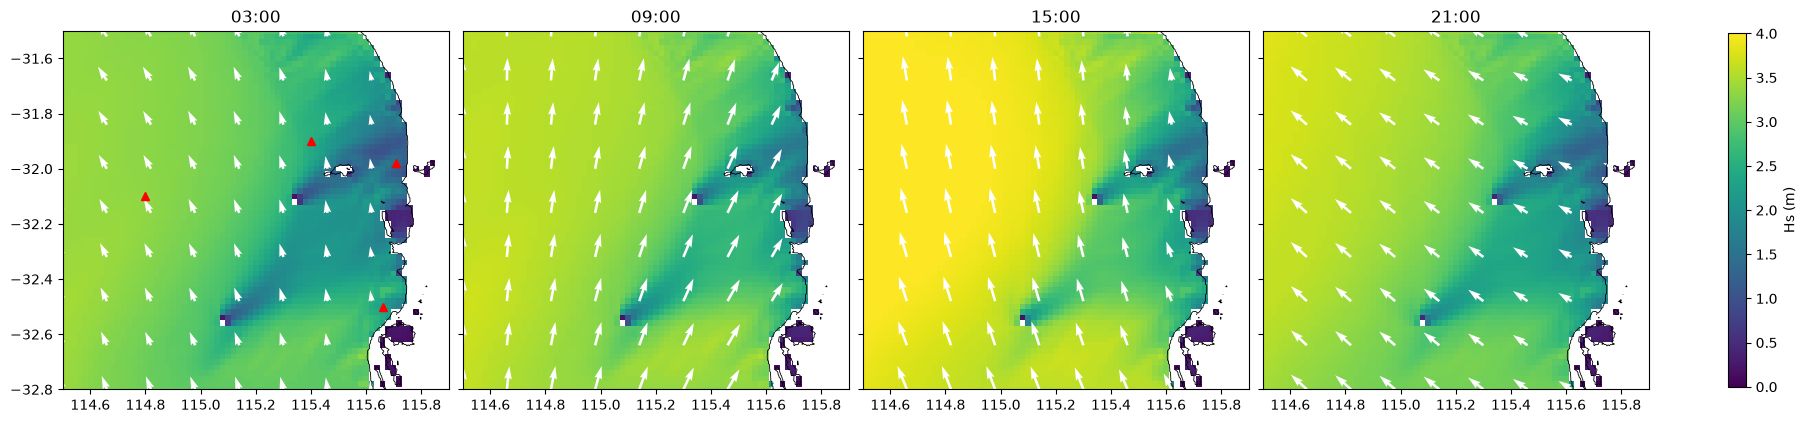

In [10]:
etopo = xr.open_dataset(DATA_DIR / "etopo15s_perth.nc")
if (workspace / "swangrid.nc").exists():
    maps = xr.open_dataset(workspace / "swangrid.nc")
    hours = ["2023-01-01T03:00", "2023-01-01T09:00", "2023-01-01T15:00", "2023-01-01T21:00"]
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True, layout="constrained")
    for ax, hour in zip(axes, hours):
        snapshot = maps.sel(time=hour)
        pm = snapshot.hs.plot(ax=ax, cmap="viridis", vmin=0, vmax=4, add_colorbar=False)
        etopo.z.plot.contour(ax=ax, levels=[0], colors="k", linewidths=0.6)
        step = snapshot.isel(longitude=slice(None, None, 8), latitude=slice(None, None, 8))
        ax.quiver(step.longitude, step.latitude, step.xwnd, step.ywnd, color="w", scale=200)
        ax.set(xlim=(114.5, 115.9), ylim=(-32.8, -31.5), title=hour[11:], xlabel="", ylabel="")
        ax.set_aspect("equal")
    for name, (x, y) in sites.items():
        axes[0].plot(x, y, "r^")
    fig.colorbar(pm, ax=axes, label="Hs (m)", shrink=0.8)

## 9. Time series at the output points

The table has one row per point and time, with `%` header lines. The four points
repeat at every time.

In [11]:
if (workspace / "sites.txt").exists():
    columns = ["time", "depth", "hs", "tps", "dir", "u10", "v10"]
    table = pd.read_csv(
        workspace / "sites.txt", comment="%", sep=r"\s+", names=columns, dtype={"time": str}
    )
    table["time"] = pd.to_datetime(table["time"], format="%Y%m%d.%H%M%S")
    table["site"] = list(sites) * (len(table) // len(sites))
    table["wind"] = (table.u10**2 + table.v10**2) ** 0.5
    print(table.groupby("site")[["depth", "hs", "tps"]].mean().round(2))

             depth    hs    tps
site                           
cottesloe    14.68  1.61  13.98
mandurah     15.10  2.34  14.49
offshore   1864.53  3.61  14.31
rottnest     46.75  2.86  14.24


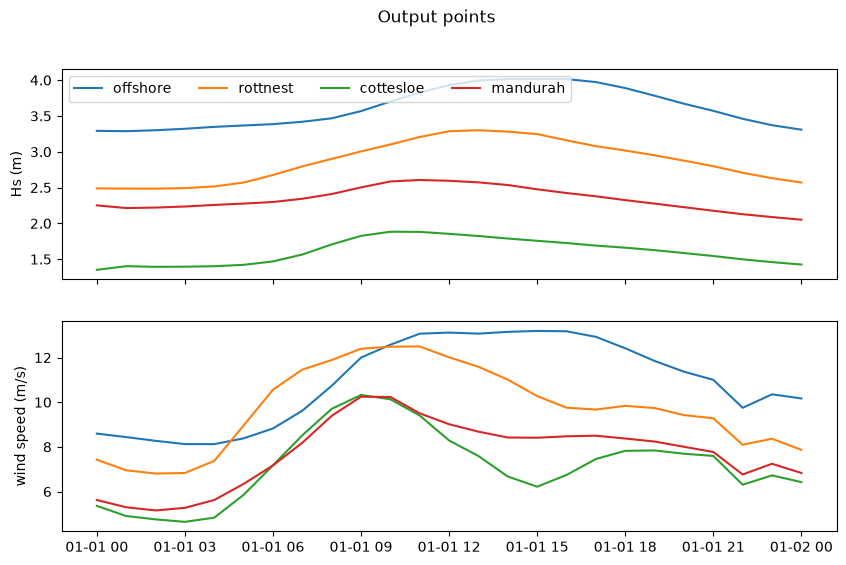

In [12]:
if (workspace / "sites.txt").exists():
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for site, group in table.groupby("site", sort=False):
        axes[0].plot(group.time, group.hs, label=site)
        axes[1].plot(group.time, group.wind, label=site)
    axes[0].set_ylabel("Hs (m)")
    axes[1].set_ylabel("wind speed (m/s)")
    axes[0].legend(ncols=4)
    fig.suptitle("Output points")

## 10. Spectra

wavespectra reads SWAN's NetCDF spectra. At 15:00 the offshore spectrum has two parts:
swell from the south-west at low frequencies, and the wind sea from the south at
higher frequencies. Off Cottesloe, the swell has turned to come from the west-south-west
as it refracted over the shelf, and little wind sea is left. Each panel is normalised
by its own maximum; the table above gives the wave heights.

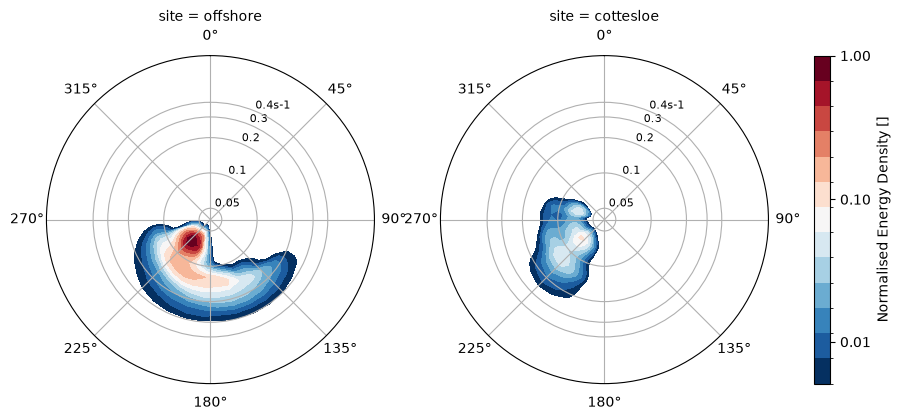

In [13]:
if (workspace / "spectra.nc").exists():
    spectra = wavespectra.read_ncswan(workspace / "spectra.nc").sel(time="2023-01-01T15:00")
    spectra = spectra.assign_coords(site=list(sites))
    spectra.sel(site=["offshore", "cottesloe"]).spec.plot(
        col="site", as_period=False, figsize=(10, 4.5)
    )

## Summary

- The run interval is the nonstationary time step: at most 10 minutes, with a Courant
  number below 10.
- `POINTS`, `BLOCK`, `TABLE` and `SPECOUT` write maps, tables and spectra; their
  `times` set the output interval.
- `COMPUTE_NONSTAT(initstat=True)` starts from a stationary solution.
- Always read `PRINT`: SWAN can stop with an error and still exit normally.

**Next:** [7. Configuration as YAML and the rompy CLI](07_yaml_and_cli.ipynb).